# Chủ đề: Nghiên cứu xây dựng mô hình học đa tác vụ kết hợp xử lý mất cân bằng lớp cho phân tích phản hồi sinh viên/UIT-VSFC

## Người thực hiện: Nguyễn Thị Thu Trang
## MSSV: 22028254

# Cài đặt, import các thư viện

In [1]:
!pip install gdown

In [2]:
import gdown
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

# Tải dữ liệu UIT-VSFC từ Google Drive

In [3]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

# I. Exploratory Data Analysis
## 1. Giới thiệu và lựa chọn dữ liệu
### Nguồn gốc của tập dữ liệu:
* Bộ dữ liệu được lấy từ nền tảng Hugging Face Datasets.
* Đây là tập dữ liệu mở, phổ biến cho các bài toán phân loại cảm xúc và chủ đề trong phản hồi của sinh viên.
* Bộ dữ liệu do nhóm UIT-NLP Lab (Đại học Công nghệ Thông tin – ĐHQG TP.HCM) phát hành.
* Link: [UIT-VSFC](https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback)

### Mô tả chung về bộ dữ liệu:
* UIT-VSFC (Vietnamese Students’ Feedback Corpus) là bộ dữ liệu gồm hơn 16.000 phản hồi của sinh viên về các khóa học, giảng viên, chương trình đào tạo và cơ sở vật chất tại trường đại học.

* Mỗi phản hồi được gán nhãn theo hai nhiệm vụ:
    * Phân loại cảm xúc (Sentiment classification): gồm 3 mức độ cảm xúc – Positive (tích cực), Neutral (trung lập) và Negative (tiêu cực).
    * Phân loại chủ đề (Topic classification): gồm 4 nhóm chủ đề – Lecturer (giảng viên), Curriculum (chương trình học), Facility (cơ sở vật chất) và Others (khác).

* Dữ liệu được chia thành ba phần: train:val:test = 70:10:20

* Dữ liệu gốc được công bố kèm trong nghiên cứu:
*Nguyen et al., “UIT-VSFC: Vietnamese Students’ Feedback Corpus for Sentiment Analysis,” KSE 2018.*

### Khám phá tổng quan

In [4]:
df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df.shape

(16175, 3)

=> Bộ dữ liệu có chính xác 16175 dòng và có 3 cột

In [5]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (11426, 3)
Validation: (1583, 3)
Test: (3166, 3)


=> Train val test đang được chia tỷ lệ xấp xỉ 70:10:20

In [6]:
df.head()

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16175 entries, 0 to 16174
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence   16175 non-null  object
 1   sentiment  16175 non-null  int64 
 2   topic      16175 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 379.2+ KB


In [8]:
train_df.isnull().sum()

sentence     0
sentiment    0
topic        0
dtype: int64

=> Có 3 cột sentence, sentiment và topic

Cả 3 cột đều không chứa giá trị null

In [9]:
df.duplicated().sum()

0

=> Dataset không có dòng nào lặp

In [10]:
df.nunique()

sentence     16174
sentiment        3
topic            4
dtype: int64

* sentiment có 3 giá trị đặc biệt
* topic có 4 giá trị đặc biệt
* Chú ý: Sentence chứa 16174 dòng có giá trị unique => Có 2 dòng lặp nhưng có giá trị sentiment và topic khác nhau

In [12]:
# Tìm các câu trùng lặp theo cột 'sentence'
duplicate_sentences = df[df.duplicated(subset="sentence", keep=False)]

# Lọc ra các trường hợp trùng câu nhưng khác sentiment hoặc topic
diff_label_duplicates = duplicate_sentences.groupby("sentence").filter(
    lambda x: x["sentiment"].nunique() > 1 or x["topic"].nunique() > 1
)

# Hiển thị kết quả
print("Số câu trùng nhưng có nhãn khác nhau:", diff_label_duplicates["sentence"].nunique())
display(diff_label_duplicates.sort_values("sentence").reset_index(drop=True))
for sent, group in diff_label_duplicates.groupby("sentence"):
    print(f"Câu trùng: {sent}\n")

Số câu trùng nhưng có nhãn khác nhau: 1


,sentence,sentiment,topic
0,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",2,0
1,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",0,0


Câu trùng: thầy dạy hay , tuy nhiên còn nhiều chỗ chưa thật sự giải đáp hoàn toàn cho sinh viên vì chưa đủ thời gian .



### Thông tin Dataset

#### Dataset gồm **3 cột**, chi tiết như sau:

| **Tên cột** | **Ý nghĩa** | **Kiểu dữ liệu** | **Dạng dữ liệu**       |
| ----------- | --------------------------------------------------------------------------------------------------- | ---------------------- |---------------------- |
| `sentence`  | Câu phản hồi (feedback) của sinh viên về khóa học, giảng viên, cơ sở vật chất hoặc chương trình học | Chuỗi ký tự      | Văn bản (text)         |
| `sentiment` | Nhãn cảm xúc của câu phản hồi: <br>`0 = Negative`, `1 = Neutral`, `2 = Positive`                    |  Số nguyên        | Danh mục (categorical) |
| `topic`     | Chủ đề phản hồi của sinh viên: <br>`0 = Lecturer`, `1 = Curriculum`, `2 = Facility`, `3 = Others`   | Số nguyên        | Danh mục (categorical) |




## 2. Thực hiện thống kê mô tả

### 2.1 Thống kê và trực quan hóa trên các dữ liệu dạng categorical

In [13]:
categorical_cols = ['sentiment', 'topic']

In [14]:
sentiment_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
topic_labels = {0: "Lecturer", 1: "Curriculum", 2: "Facility", 3: "Others"}

In [15]:
temp_df = df.copy()
# Map nhãn hiển thị
sentiment_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
topic_labels = {0: "Lecturer", 1: "Curriculum", 2: "Facility", 3: "Others"}
temp_df["sentiment_label"] = temp_df["sentiment"].map(sentiment_labels)
temp_df["topic_label"] = temp_df["topic"].map(topic_labels)
temp_df.head()

,sentence,sentiment,topic,sentiment_label,topic_label
0,slide giáo trình đầy đủ .,2,1,Positive,Curriculum
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,Positive,Lecturer
2,đi học đầy đủ full điểm chuyên cần .,0,1,Negative,Curriculum
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,Negative,Lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,Positive,Lecturer



Cột: sentiment


,Số lượng,Tỷ lệ (%)
sentiment_label,,
Positive,8038,49.69
Negative,7439,45.99
Neutral,698,4.32


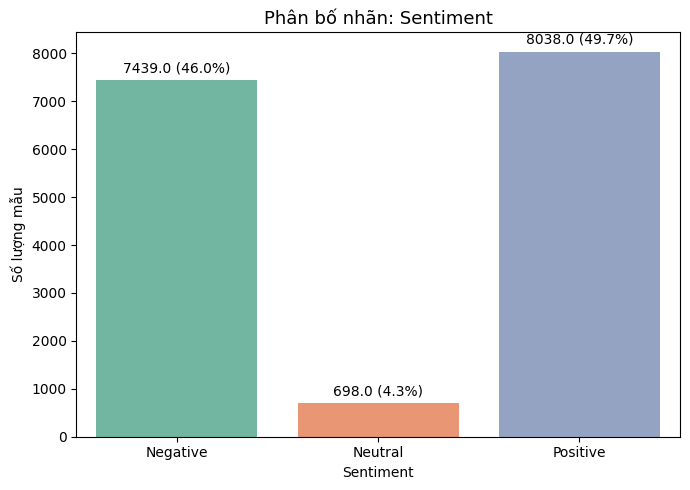


Cột: topic


,Số lượng,Tỷ lệ (%)
topic_label,,
Lecturer,11607,71.76
Curriculum,3040,18.79
Others,816,5.04
Facility,712,4.40


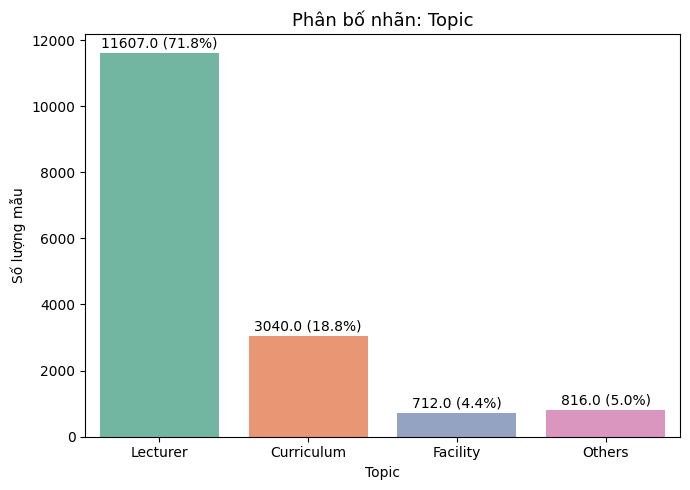

In [16]:
def print_categorical_summary(df, col):
    label_map = sentiment_labels if col == 'sentiment' else topic_labels

    # Tính số lượng & tỷ lệ
    summary = df[f"{col}_label"].value_counts().to_frame("Số lượng")
    summary["Tỷ lệ (%)"] = (summary["Số lượng"] / len(df) * 100).round(2)
    display(summary)

    # Vẽ biểu đồ
    plt.figure(figsize=(7, 5))
    ax = sns.countplot(x=f"{col}_label", data=df, palette="Set2", order=label_map.values())
    plt.title(f"Phân bố nhãn: {col.capitalize()}", fontsize=13)
    plt.xlabel(col.capitalize())
    plt.ylabel("Số lượng mẫu")

    # Hiển thị số lượng + tỷ lệ trên cột
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2, height + total * 0.01, 
                f"{height} ({height/total*100:.1f}%)",
                ha="center", fontsize=10, color="black")

    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    print(f"\nCột: {col}")
    print_categorical_summary(temp_df, col)

#### Nhận xét: 
=> Mất cân bằng nhãn:
* Sentiment: Lớp Neutral quá ít so với Positive và Negative
* Topic:
    * Lớp Lecturer chiếm đa số(71.8%)
    * Lớp Curiculum chiếm thứ 2 (18.8%)
    * 2 lớp còn lại là Facility và Others thì chiếm 1 phần nhỏ rất nhỏ là 4.4% và 5.0%

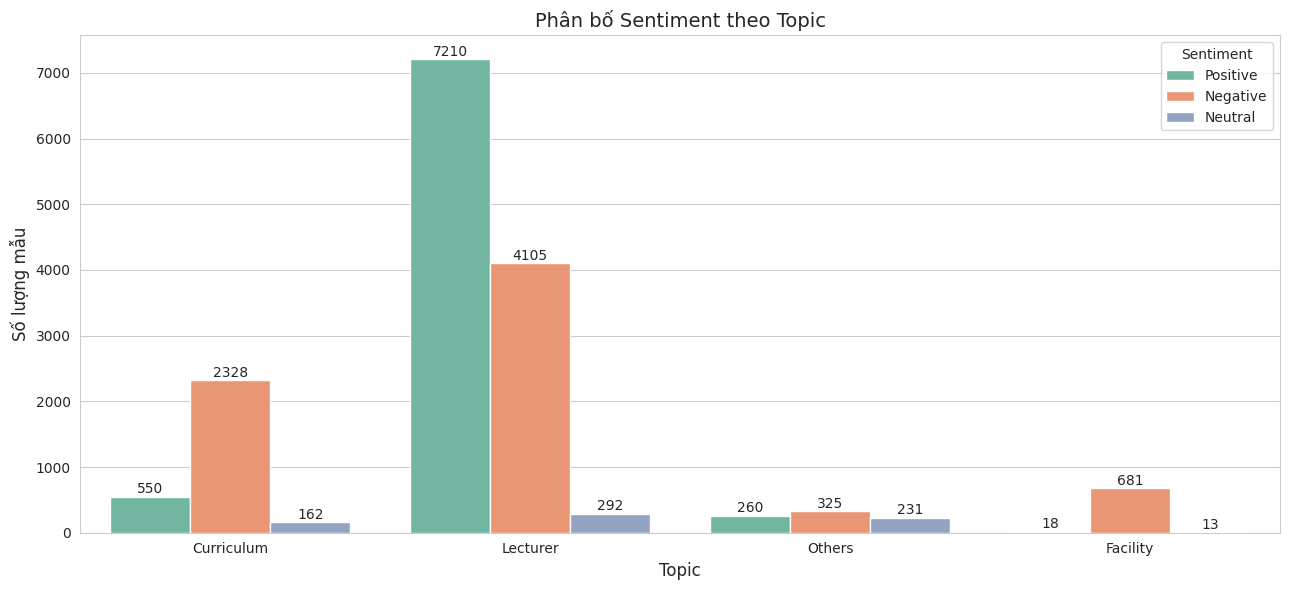

In [17]:
def plot_sentiment_by_topic(df, palette='Set2'):
    """Vẽ biểu đồ phân bố sentiment theo topic"""
    sns.set_style("whitegrid")

    plt.figure(figsize=(13, 6))
    ax = sns.countplot(
        x="topic_label", hue="sentiment_label",
        data=df, palette=palette
    )

    # Ghi số lượng trên cột
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width()/2, height + 3,
                    f"{int(height)}", ha="center", va="bottom", fontsize=10)

    # Tùy chỉnh hiển thị
    ax.set_title("Phân bố Sentiment theo Topic", fontsize=14)
    ax.set_xlabel("Topic", fontsize=12)
    ax.set_ylabel("Số lượng mẫu", fontsize=12)
    ax.legend(title="Sentiment", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_sentiment_by_topic(temp_df)

Bảng tỷ lệ (%) sentiment theo topic:


sentiment_label,Negative,Neutral,Positive,Total
Curriculum,76.58,5.33,18.09,100.0
Facility,95.65,1.83,2.53,100.0
Lecturer,35.37,2.52,62.12,100.0
Others,39.83,28.31,31.86,100.0
Total,61.86,9.49,28.65,100.0


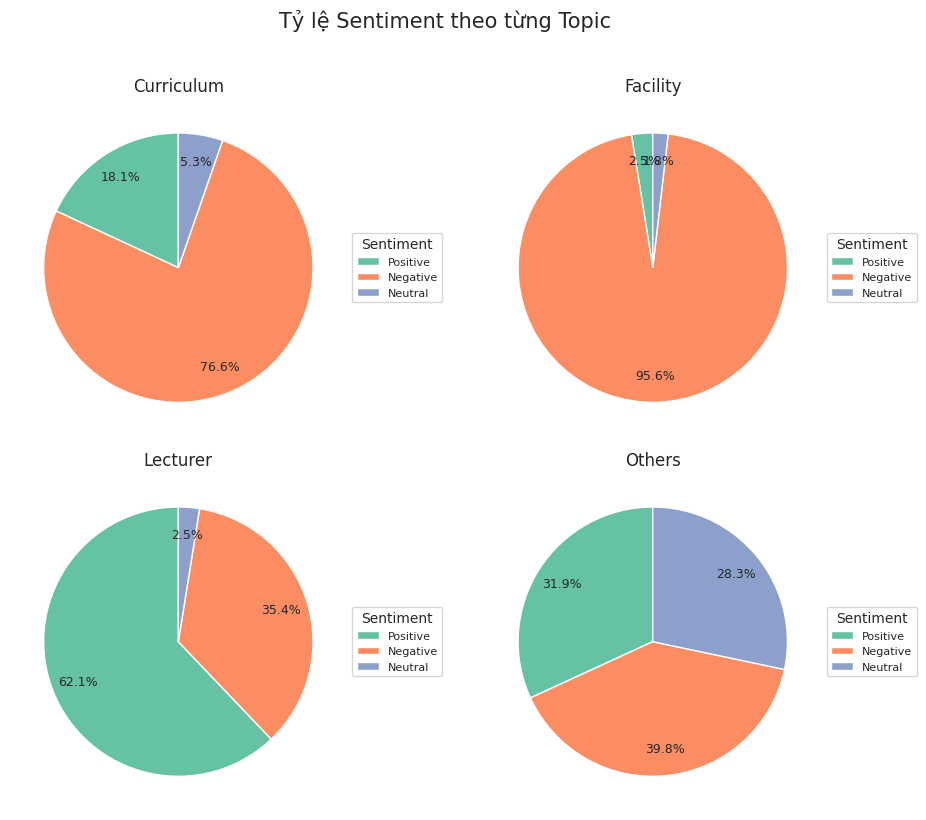

In [18]:
def pie_sentiment_by_topic(df):
    """Tạo bảng tổng hợp và vẽ biểu đồ tròn sentiment theo topic (2x2 layout)"""
    # Tạo bảng tỉ lệ (%)
    cross_tab = pd.crosstab(df["topic_label"], df["sentiment_label"], normalize="index") * 100
    cross_tab["Total"] = cross_tab.sum(axis=1)
    total_row = cross_tab.mean(axis=0)
    total_row.name = "Total"
    cross_tab = pd.concat([cross_tab, total_row.to_frame().T]).round(2)

    # Hiển thị bảng
    print("Bảng tỷ lệ (%) sentiment theo topic:")
    display(cross_tab)

    # Thiết lập màu và danh sách topic
    colors = sns.color_palette("Set2", n_colors=3)
    topics = [t for t in cross_tab.index if t != "Total"]

    # Vẽ subplot 2x2
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, topic in zip(axes, topics):
        values = cross_tab.loc[topic, ["Positive", "Negative", "Neutral"]]
        wedges, texts, autotexts = ax.pie(
            values,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            textprops={'fontsize': 9},
            pctdistance=0.8
        )
        ax.set_title(topic, fontsize=12)
        ax.legend(
            wedges, values.index, title="Sentiment",
            loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8
        )

    # Ẩn ô thừa nếu có
    for ax in axes[len(topics):]:
        ax.axis("off")

    plt.suptitle("Tỷ lệ Sentiment theo từng Topic", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
pie_sentiment_by_topic(temp_df)

#### Nhận xét: 
* Phần lớn phản hồi về Curriculum (chương trình học) là tiêu cưc
* Phần lớn phản hồi về Lecturer (giảng viên) là tích cực
* Phần lớn phản hồi về Facility (cơ sở vật chất) là tiêu cực
* Còn đối với Other thì tỷ lệ khá cân bằng giữa Positive Negative và Neutral

### 2.2 Thống kê và trực quan hóa trên dữ liệu dạng text

Thống kê độ dài câu (số từ):


count    16175.00
mean        14.23
std         10.10
min          2.00
25%          8.00
50%         11.00
75%         17.00
max        161.00
Name: word_count, dtype: float64

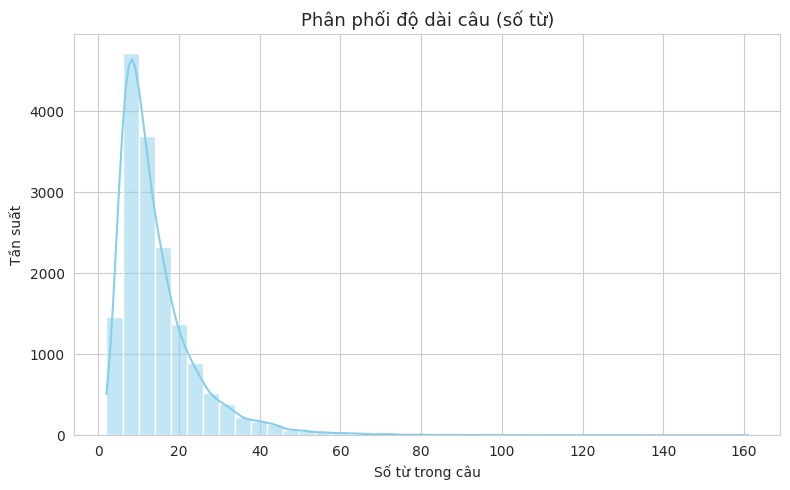

In [19]:
text_df = temp_df.copy()

# Tính độ dài câu (số từ)
text_df["word_count"] = text_df["sentence"].apply(lambda x: len(str(x).split()))
text_df["char_count"] = text_df["sentence"].apply(lambda x: len(str(x)))

# Thống kê cơ bản
print("Thống kê độ dài câu (số từ):")
display(text_df["word_count"].describe().round(2))

# Biểu đồ phân phối độ dài câu
plt.figure(figsize=(8,5))
sns.histplot(text_df["word_count"], bins=40, kde=True, color="skyblue")
plt.title("Phân phối độ dài câu (số từ)", fontsize=13)
plt.xlabel("Số từ trong câu")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.show()

#### Nhận xét:
* Độ dài phản hồi dao động từ 2 → 161 từ, cho thấy sự đa dạng cao: có phản hồi ngắn kiểu “Tốt lắm”, và có phản hồi dài mô tả chi tiết.
* Trung vị 11 từ nghĩa là một nửa phản hồi có dưới 11 từ, đa phần là các câu ngắn gọn.
* Độ dài trung bình 14.2 từ, khá ngắn, phù hợp với đặc thù phản hồi sinh viên (dạng survey hoặc ý kiến nhanh).
* Độ lệch chuẩn 10.1 → có một số phản hồi rất dài, thể hiện sự nhiệt tình hoặc phàn nàn chi tiết.
* Các phản hồi > 50 từ là outlier (ngoại lệ), có thể xem xét riêng trong bước tiền xử lý (chuẩn hóa, cắt bớt nếu cần).

,Độ dài TB (số từ)
sentiment_label,
Negative,16.89
Neutral,9.82
Positive,12.15


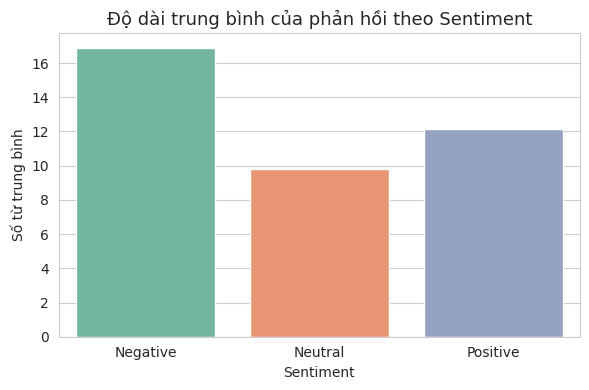

In [20]:
# Tính trung bình độ dài theo nhãn cảm xúc
avg_len_by_sent = text_df.groupby("sentiment_label")["word_count"].mean().round(2)
display(avg_len_by_sent.to_frame("Độ dài TB (số từ)"))

# Biểu đồ
plt.figure(figsize=(6,4))
sns.barplot(x=avg_len_by_sent.index, y=avg_len_by_sent.values, palette="Set2")
plt.title("Độ dài trung bình của phản hồi theo Sentiment", fontsize=13)
plt.xlabel("Sentiment")
plt.ylabel("Số từ trung bình")
plt.tight_layout()
plt.show()

#### Nhận xét:
* Phản hồi tiêu cực có xu hướng dài hơn nhiều so với phản hồi tích cực và trung tính
* Phản hồi tích cực có xu hướng dài hơn 1 chút so với phản hồi trung tính

,Độ dài TB (số từ)
topic_label,
Curriculum,16.76
Facility,16.97
Lecturer,13.70
Others,9.95


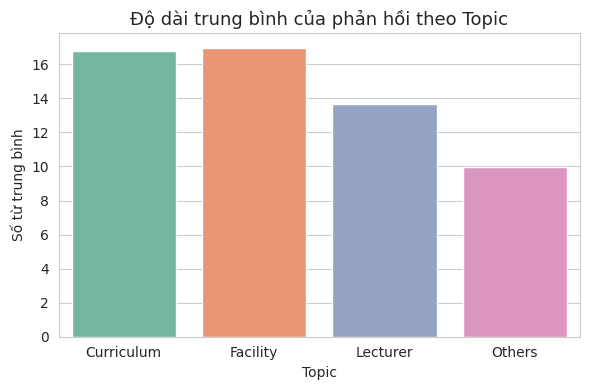

In [21]:
# Tính trung bình độ dài theo nhãn cảm xúc
avg_len_by_sent = text_df.groupby("topic_label")["word_count"].mean().round(2)
display(avg_len_by_sent.to_frame("Độ dài TB (số từ)"))

# Biểu đồ
plt.figure(figsize=(6,4))
sns.barplot(x=avg_len_by_sent.index, y=avg_len_by_sent.values, palette="Set2")
plt.title("Độ dài trung bình của phản hồi theo Topic", fontsize=13)
plt.xlabel("Topic")
plt.ylabel("Số từ trung bình")
plt.tight_layout()
plt.show()

#### Nhận xét:
* Phản hồi về Curriculum và Facility có độ dài trung bình ngang nhau khoảng gần 17 từ, cao nhất.
* Phản hồi về Lecturer cao nhì với độ dài trung bình khoảng 14 từ.
* Phản hồi về Others thấp nhất với độ dài trung bình khoảng 10 từ.

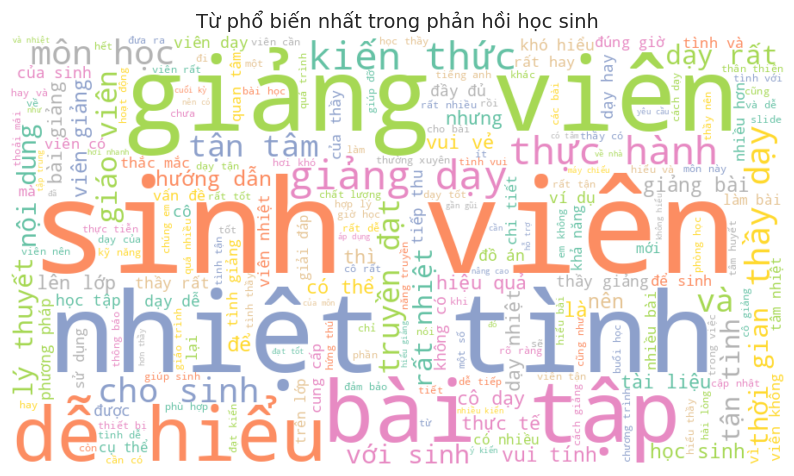

In [22]:
from wordcloud import WordCloud

# Gộp toàn bộ câu thành 1 chuỗi
all_text = " ".join(text_df["sentence"].astype(str).tolist())

wordcloud = WordCloud(width=900, height=500, background_color='white',
                      colormap='Set2', font_path=None).generate(all_text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Từ phổ biến nhất trong phản hồi học sinh", fontsize=14)
plt.show()

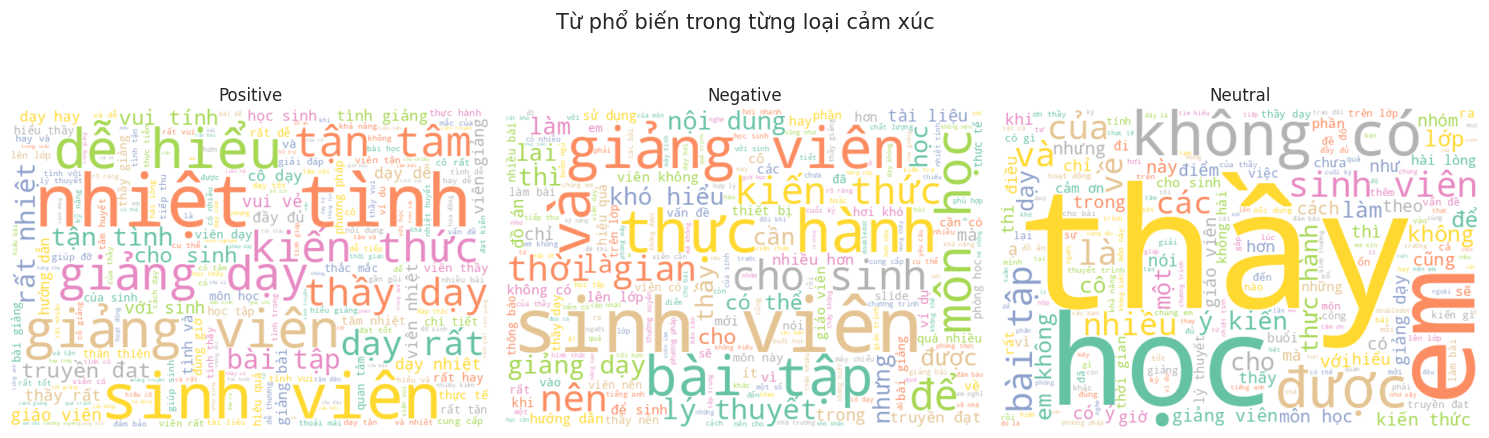

In [23]:
sentiments = ["Positive", "Negative", "Neutral"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, s in zip(axes, sentiments):
    text = " ".join(text_df[text_df["sentiment_label"] == s]["sentence"].astype(str))
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="Set2", font_path=None).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(s, fontsize=12)

plt.suptitle("Từ phổ biến trong từng loại cảm xúc", fontsize=15)
plt.tight_layout()
plt.show()

In [24]:
print("Một vài phản hồi tiêu biểu:\n")

for label in ["Positive", "Negative", "Neutral"]:
    print(f"{label}")
    examples = text_df[text_df["sentiment_label"] == label]["sentence"].sample(3, random_state=42).tolist()
    for e in examples:
        print("•", e)
    print()

Một vài phản hồi tiêu biểu:

Positive
• nhiệt tình , khá dễ hiểu .
• đồng thời , những câu hỏi thầy đặt ra rất sát và đòi hỏi kiến thức sâu so với bài học .
• thảo luận hay .

Negative
• phòng máy không đảm bảo , nhiều máy bị hư , các bạn sinh viên phải mang laptop theo , rất cực .
• nhiều lúc nói chuyện ngoài lề hơi nhiều , dạy thâm giờ .
• đề nghị bỏ phần thì lý thuyết vào cuối kỳ , chỉ lấy 2 cột điểm seminar giữa kỳ và đồ án cuối kỳ .

Neutral
• phần cho điểm , nội dung ôn thi .
• nhanh .
• phương thức giảng dạy .



In [25]:
print("Một vài phản hồi tiêu biểu:\n")

for label in ["Lecturer", "Curriculum", "Facility", "Others"]:
    print(f"{label}")
    examples = text_df[text_df["topic_label"] == label]["sentence"].sample(3, random_state=42).tolist()
    for e in examples:
        print("•", e)
    print()

Một vài phản hồi tiêu biểu:

Lecturer
• giảng viên nhiệt tình , dạy dễ hiểu .
• thầy giảng dạy rất lôi cuốn và dễ hiểu .
• cô giảng và dạy rất nhiệt tình .

Curriculum
• buổi nào cũng có thực hành, học lý thuyết xong ra thực hành liền sẽ có hiệu quả cao !
• không biết gì sau khi học môn này .
• nội dung thực hành nên thay đổi doubledot mỗi tuần thực hành các phần lý thuyết trên lớp và giảng viên hướng dẫn làm đồ án cuối kỳ .

Facility
• mini test trong cả khóa học nhiều hơn .
• phòng học , bàn ghế còn bẩn và nhiều bụi bặm .
• cần nâng cao chất lượng phòng máy .

Others
• em cảm thấy khá bức xúc nhưng nếu truy ra lỗi của ai thì em tự nhận một phần về mình .
• tiếng anh .
• vì thời gian trong lớp tập trung hơn .

